In [2]:
import multiprocessing as mp
mp.set_start_method("spawn", force=True)

### automatically refresh the buffer
%load_ext autoreload
%autoreload 2

### solve the auto-complete issue

%config Completer.use_jedi = False
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

### lvl 2 setups (systerm)
import os
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.stats import linregress
from matplotlib.colors import ListedColormap,LinearSegmentedColormap,BoundaryNorm
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime
import shap
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

In [3]:
df_ena_abs = pd.read_csv('/data/ggong/ARM_monthly/ENA/csv_file/df_abs.csv')
df_sgp_abs = pd.read_csv('/data/ggong/ARM_monthly/SGP/csv_file/df_abs.csv')
df_ena_ano = pd.read_csv('/data/ggong/ARM_monthly/ENA/csv_file/df_anom.csv')
df_sgp_ano = pd.read_csv('/data/ggong/ARM_monthly/SGP/csv_file/df_anom.csv')

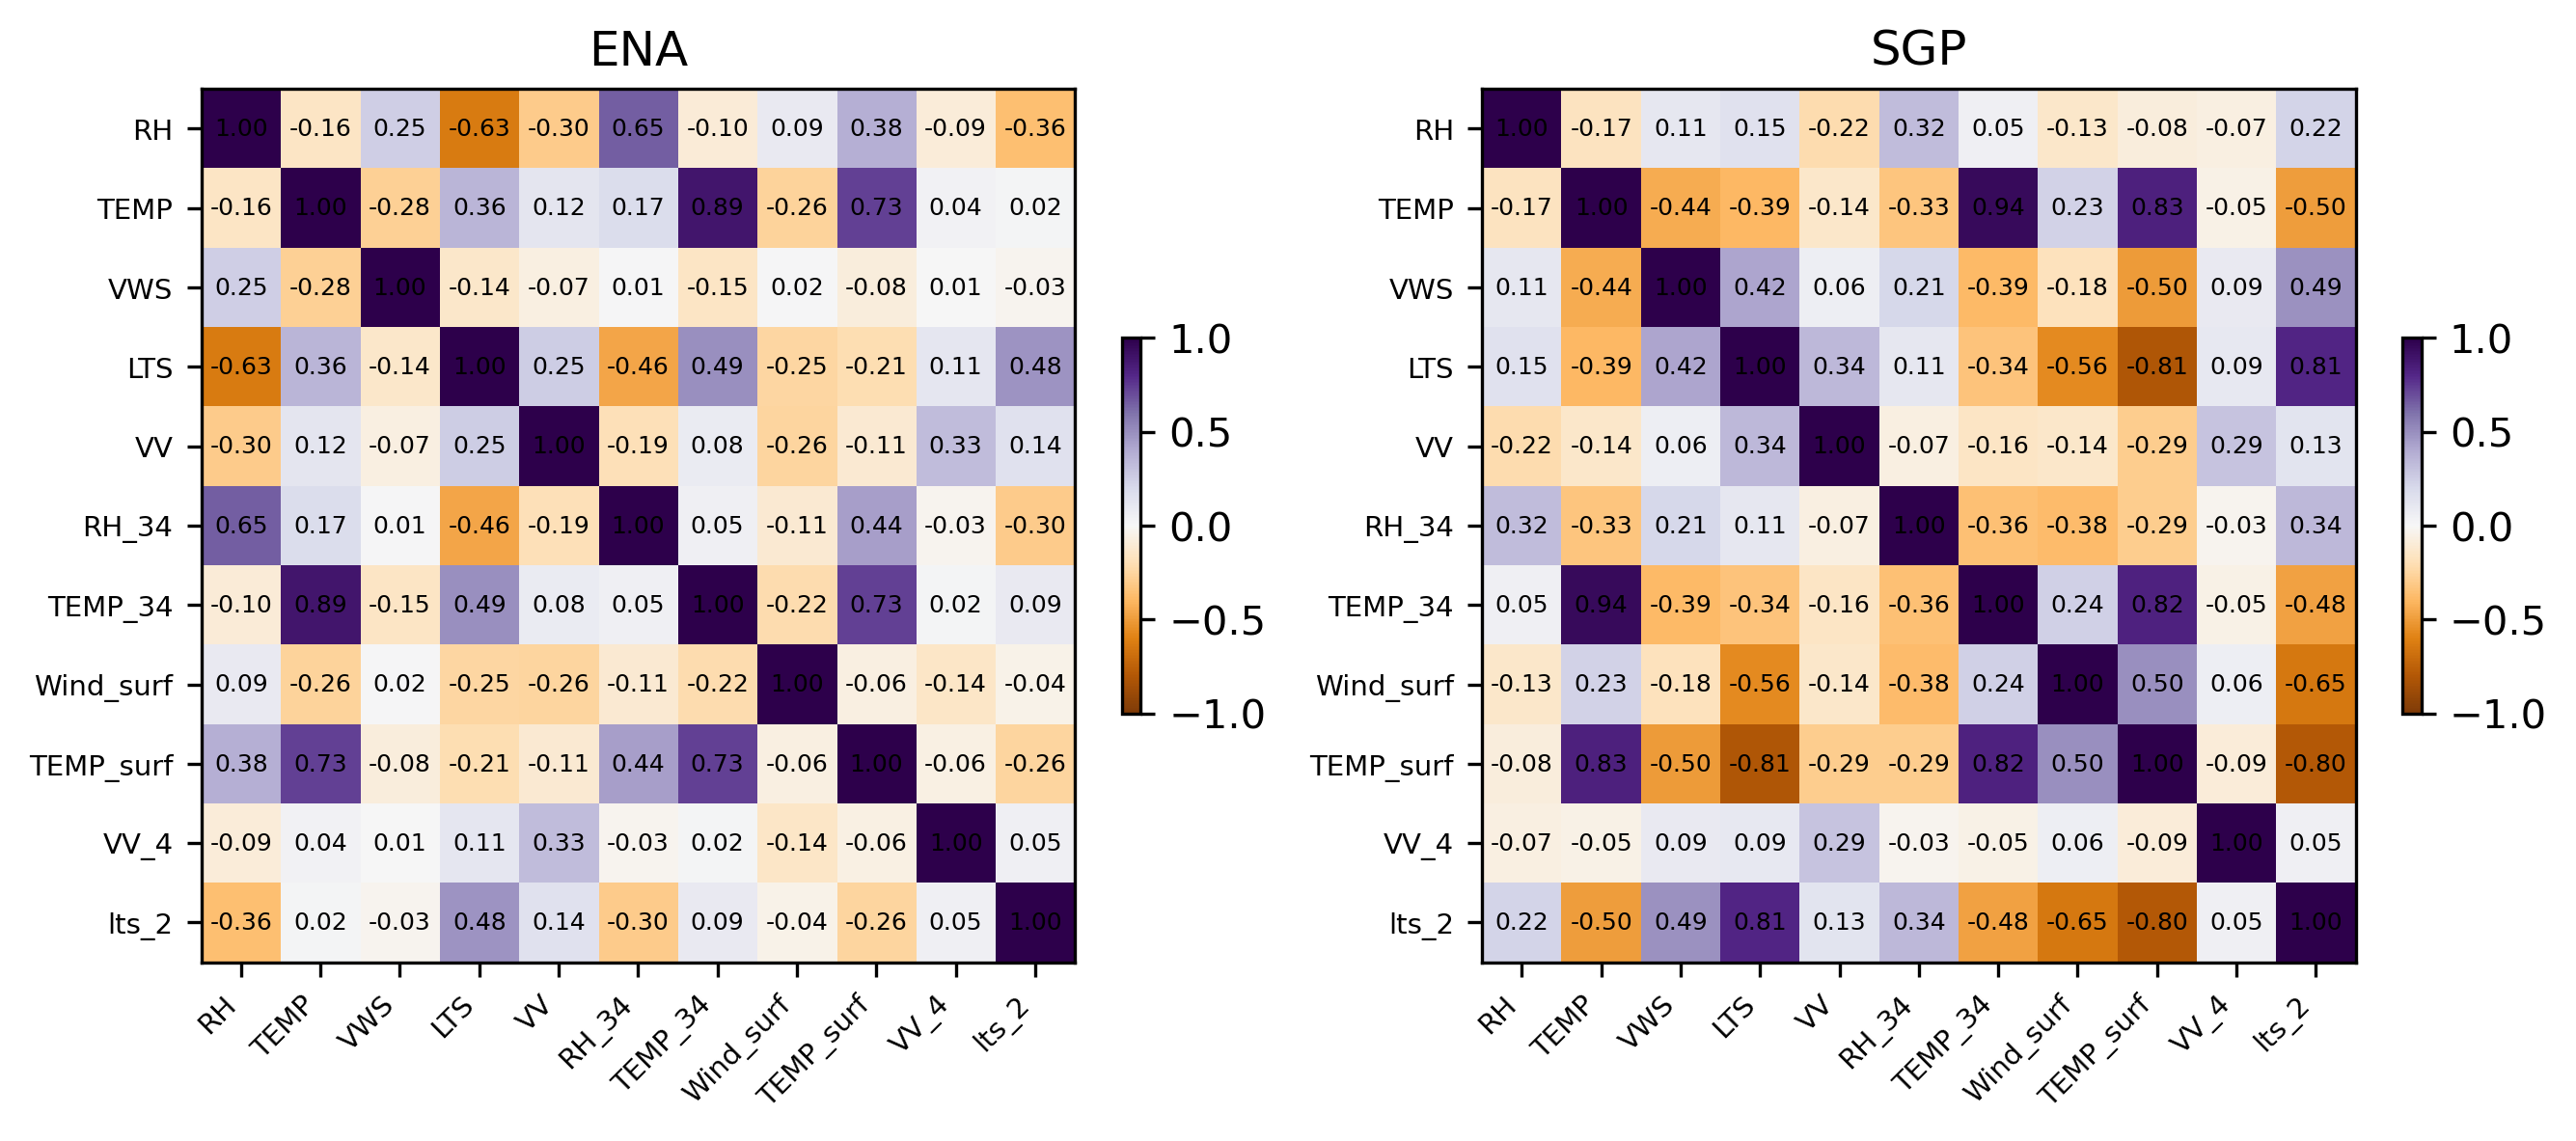

In [15]:
import numpy as np
import matplotlib.pyplot as plt

vars_all = [
'RH','TEMP','VWS','LTS','VV',
    'RH_34','TEMP_34','Wind_surf','TEMP_surf',
    'VV_4','lts_2',
]


def prep(df):
    df = df.copy()
    return df[vars_all].dropna().corr()

corrs = [prep(df_ena_abs), prep(df_sgp_abs)]
titles = ['ENA','SGP']

fig, axes = plt.subplots(1,2,figsize=(9,5),dpi=300)

for ax, corr, t in zip(axes, corrs, titles):
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap='PuOr')
    ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
    ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(corr.columns, fontsize=7)

    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center', fontsize=6)

    ax.set_title(t)
    plt.colorbar(im, ax=ax, fraction=0.02)

plt.tight_layout()
plt.savefig("figsave/Coor.pdf", dpi=300, bbox_inches='tight')
plt.show()

## MLR

## data from Lin's Paper


============ ENA ============

[top]
 lnDOD:   0.0371 ± 0.0237
    RH:  -0.0033 ± 0.0023
  TEMP:   0.0371 ± 0.0150
   LTS:  -0.0484 ± 0.0239
   VWS:   0.0150 ± 0.0134
    VV:   0.0591 ± 0.0447

[middle]
 lnDOD:   0.0007 ± 0.0089
    RH:  -0.0038 ± 0.0007
  TEMP:   0.0297 ± 0.0043
   LTS:  -0.0160 ± 0.0075
   VWS:  -0.0020 ± 0.0040
    VV:   0.0236 ± 0.0073

[bottom]
 lnDOD:   0.0131 ± 0.0068
    RH:  -0.0028 ± 0.0005
  TEMP:   0.0339 ± 0.0027
   LTS:   0.0012 ± 0.0050
   VWS:  -0.0118 ± 0.0029
    VV:   0.0383 ± 0.0057

============ SGP ============

[top]
Not enough samples

[middle]
 lnDOD:   0.0157 ± 0.0152
    RH:  -0.0009 ± 0.0012
  TEMP:   0.0090 ± 0.0039
   LTS:   0.0130 ± 0.0048
   VWS:  -0.0131 ± 0.0046
    VV:   0.0278 ± 0.0123

[bottom]
 lnDOD:   0.0439 ± 0.0113
    RH:   0.0021 ± 0.0007
  TEMP:   0.0035 ± 0.0036
   LTS:   0.0077 ± 0.0032
   VWS:   0.0065 ± 0.0031
    VV:   0.0173 ± 0.0082


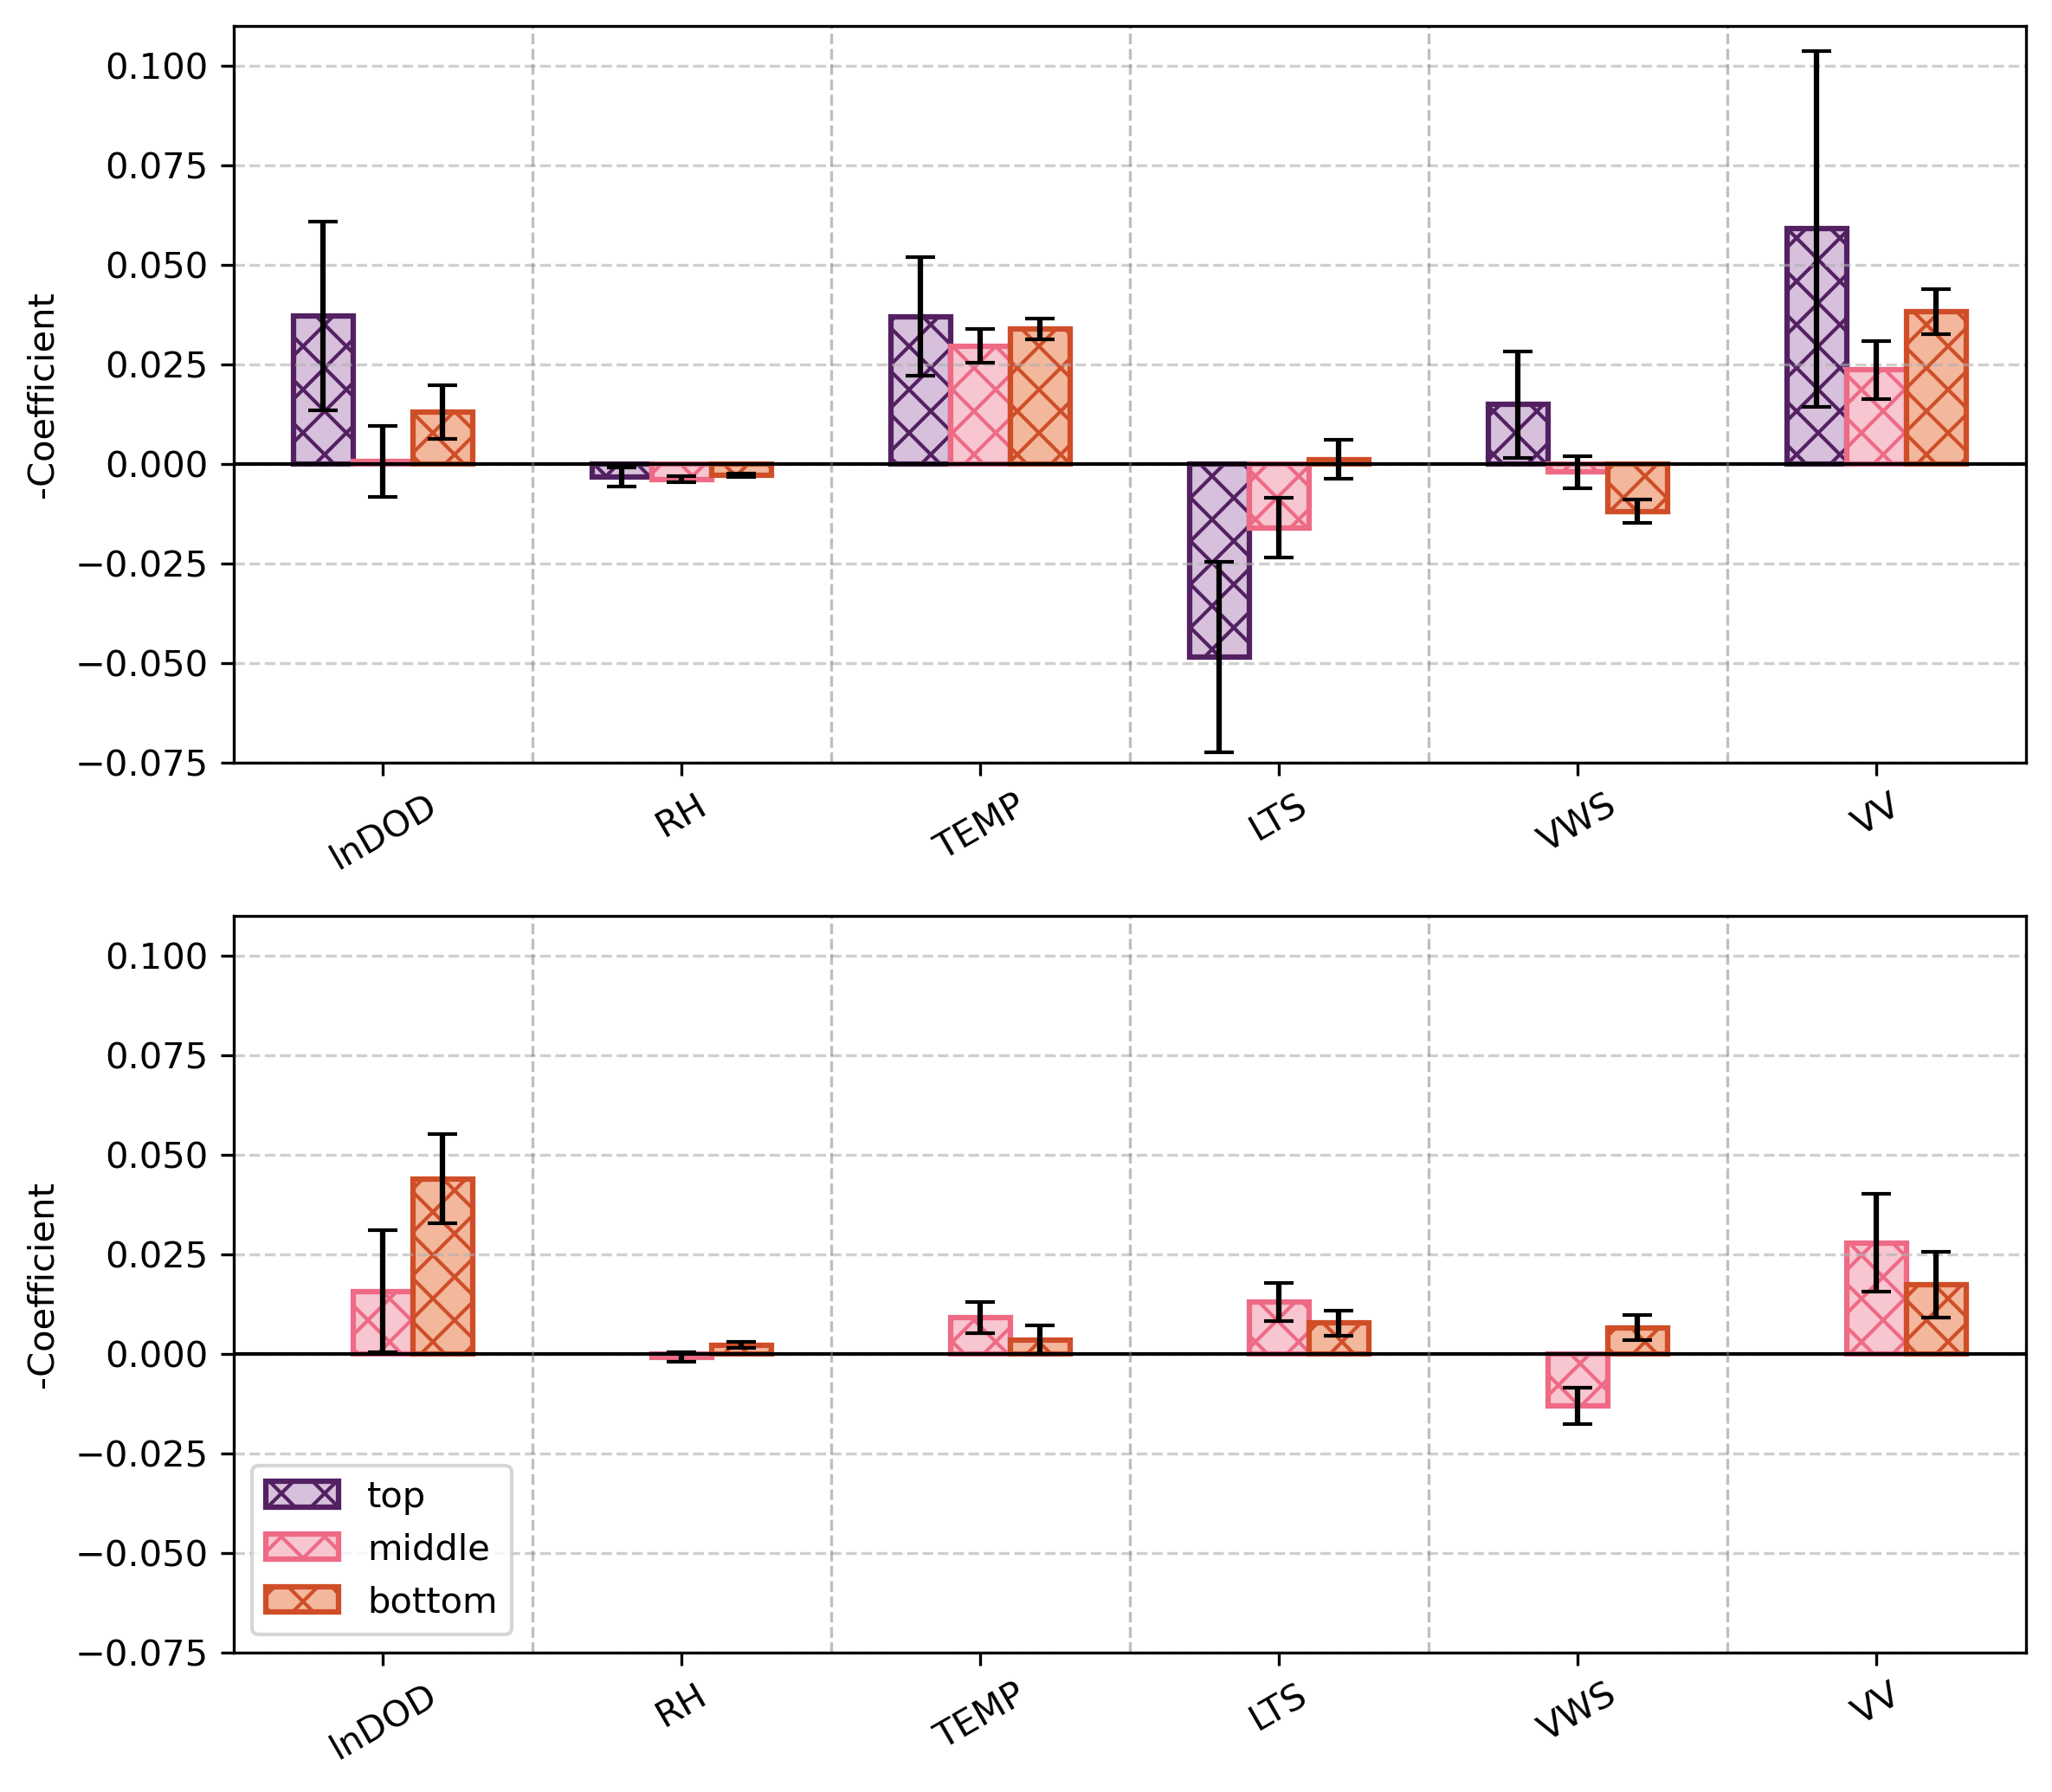

In [21]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

met_vars = ['RH','TEMP','LTS','VWS','VV']
cats = ['top','middle','bottom']
cols_all = ["#d6c0db", "#f7c6d0", "#f3b79c"]
edge_all = ["#532162", "#ee6a85", "#cf4e28"]

def safe_log(x):
    x = x.astype(float)
    x[x <= 0] = np.nan
    return np.log(x)

def get_results(df, min_n=15):
    out = {}
    for c in cats:
        d = df[df['label'] == c][['Re','main_dod'] + met_vars].copy()
        d['lnRe'] = safe_log(d['Re'])
        d['lnDOD'] = safe_log(d['main_dod'])
        d = d.dropna()
        out[c] = None if len(d) < min_n else sm.OLS(d['lnRe'], sm.add_constant(d[['lnDOD'] + met_vars])).fit()
    return out

def print_results(res, site):
    vars_plot = ['lnDOD'] + met_vars
    print(f'\n{"="*12} {site} {"="*12}')
    for c in cats:
        print(f'\n[{c}]')
        if res[c] is None:
            print('Not enough samples')
            continue
        p = -res[c].params.reindex(['const'] + vars_plot).drop('const')
        b =  res[c].bse.reindex(['const'] + vars_plot).drop('const')
        for v in vars_plot:
            print(f'{v:>6}: {p[v]:8.4f} ± {b[v]:6.4f}')

def plot_results(res_list, site_names):
    vars_plot = ['lnDOD'] + met_vars
    x, w = np.arange(len(vars_plot)), 0.2
    fig, axes = plt.subplots(2, 1, figsize=(8,7), dpi=300, sharey=True)

    for ax, res, site in zip(axes, res_list, site_names):
        for i, c in enumerate(cats):
            if res[c] is None:
                vals = np.full(len(vars_plot), np.nan)
                errs = np.full(len(vars_plot), np.nan)
            else:
                vals = -res[c].params.reindex(['const'] + vars_plot).drop('const').values
                errs =  res[c].bse.reindex(['const'] + vars_plot).drop('const').values

            ax.bar(
                x + (i-1)*w, vals, w, yerr=errs, capsize=4,
                facecolor=cols_all[i], edgecolor=edge_all[i],
                linewidth=1.5, hatch='xx', label=c
            )

        ax.axhline(0, lw=1, color='k')
        for xi in x[:-1]:
            ax.axvline(xi+0.5, ls='--', lw=0.8, color='gray', alpha=0.5)
        ax.grid(axis='y', ls='--', alpha=0.6)
        ax.set_xlim(-0.5, len(vars_plot)-0.5)
        ax.set_ylim(-0.075, 0.11)
        ax.set_xticks(x)
        ax.set_xticklabels(vars_plot, rotation=30)
        ax.set_ylabel('-Coefficient')

    axes[1].legend()
    plt.tight_layout()
    plt.savefig("figsave/METE.pdf", dpi=300, bbox_inches='tight')
    plt.show()

res_ena = get_results(df_ena_abs)
res_sgp = get_results(df_sgp_abs)

print_results(res_ena, 'ENA')
print_results(res_sgp, 'SGP')

plot_results([res_ena, res_sgp], ['ENA', 'SGP'])

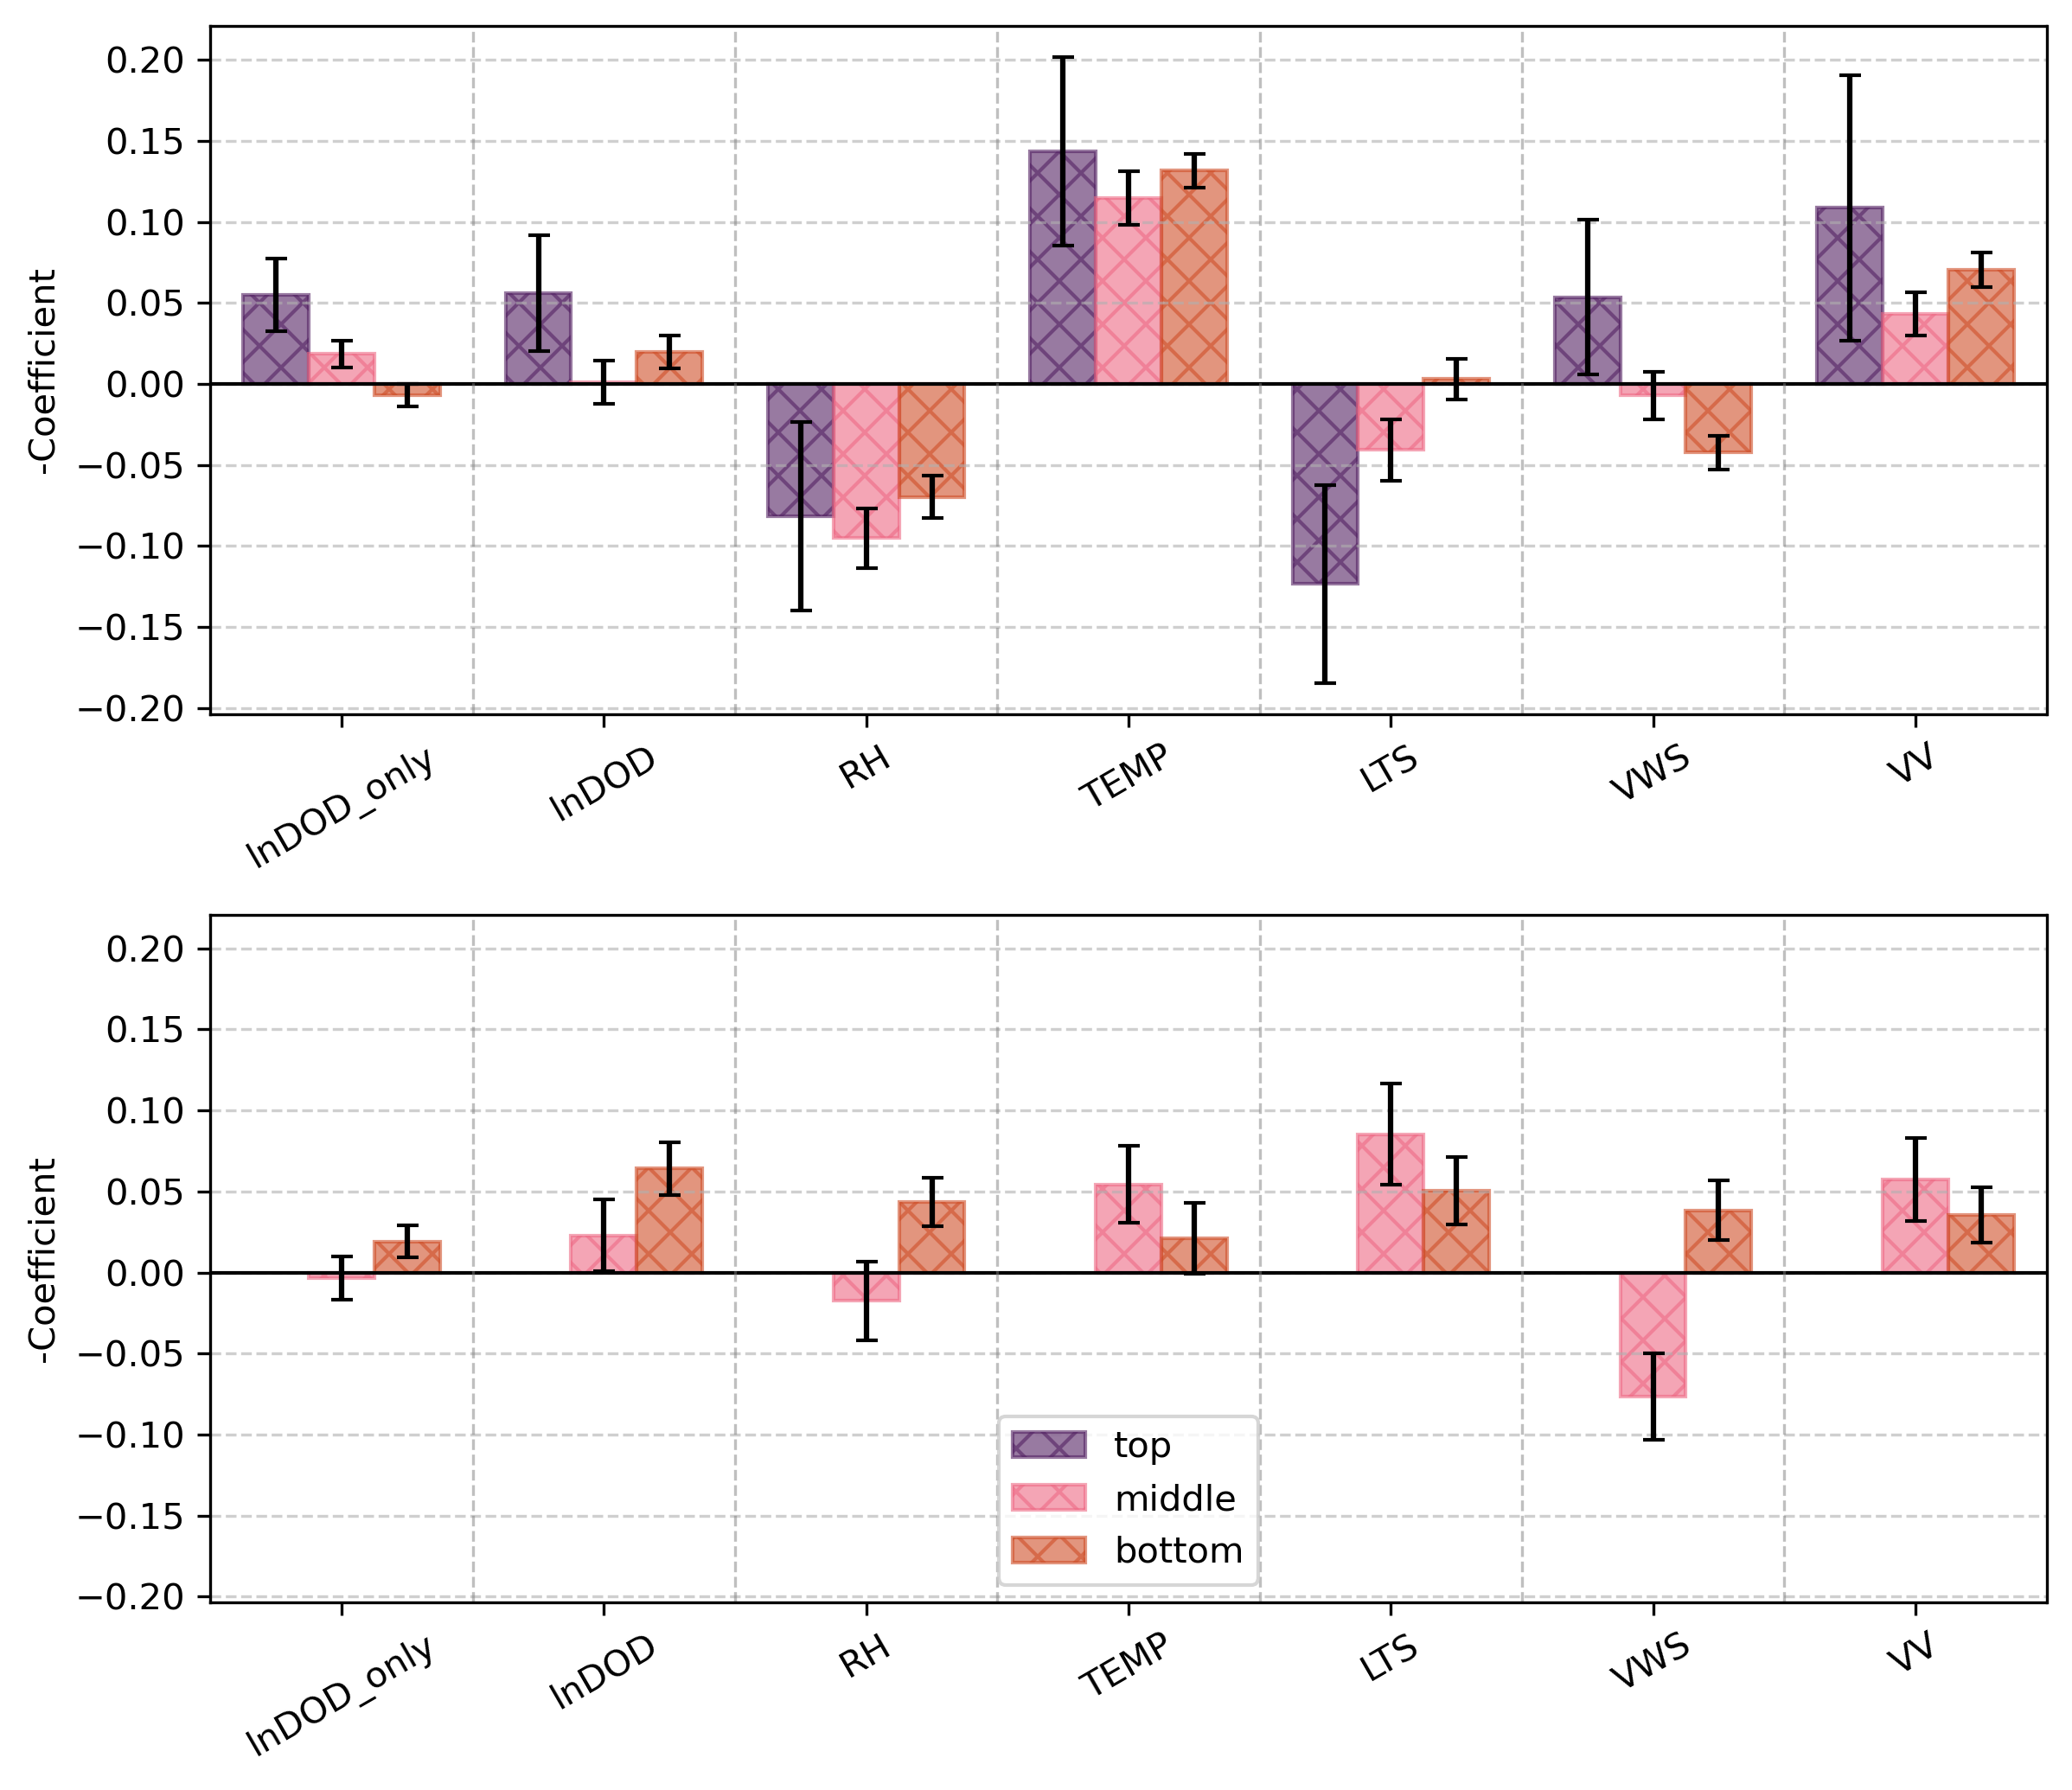

In [5]:
met_vars = ['RH','TEMP','LTS','VWS','VV',]
cats = ['top','middle','bottom']
cat_colors = {"top":"#532162","middle":"#ee6a85","bottom":"#cf4e28"}

def safe_log(x):
    x = x.astype(float)
    x[x <= 0] = np.nan
    return np.log(x)

def zscore(s):
    s = s.astype(float)
    sd = s.std()
    return (s - s.mean()) / sd if sd > 0 else np.nan

def prep_std_df(df):
    cols = ['label','Re','main_dod'] + met_vars
    d = df[cols].copy()
    d['lnRe'] = safe_log(d['Re'])
    d['lnDOD'] = safe_log(d['main_dod'])
    d = d.drop(columns=['Re','main_dod'])
    for v in ['lnDOD'] + met_vars:
        d[v] = zscore(d[v])
    return d

def get_results_std(df, min_n=15):
    d = prep_std_df(df)
    res = {}
    for c in cats:
        dc = d[d['label'] == c][['lnRe','lnDOD'] + met_vars].dropna().copy()
        res[c] = None if len(dc) < min_n else sm.OLS(dc['lnRe'], sm.add_constant(dc[['lnDOD'] + met_vars])).fit()
    return res

res_ena = get_results_std(df_ena_abs, min_n=15)
res_sgp = get_results_std(df_sgp_abs, min_n=15)

simple = [
    {'top':0.0550, 'middle':0.0185, 'bottom':-0.0069},
    {'top':np.nan, 'middle':-0.0036, 'bottom':0.0192}
]
se = [
    {'top':0.0226, 'middle':0.0081, 'bottom':0.0069},
    {'top':np.nan, 'middle':0.0133, 'bottom':0.0101}
]

vars_all = ['lnDOD'] + met_vars
vars_new = ['lnDOD_only'] + vars_all
x = np.arange(len(vars_new))
w = 0.25

fig, axes = plt.subplots(2, 1, figsize=(8, 7), dpi=300, sharey=True)

for ax, res, s, e,in zip(
    axes,
    [res_ena, res_sgp],
    simple,
    se,
):
    for i, c in enumerate(cats):
        if res[c] is None:
            vals = np.full(len(vars_new), np.nan)
            errs = np.full(len(vars_new), np.nan)
        else:
            p = res[c].params.reindex(['const'] + vars_all).drop('const')
            b = res[c].bse.reindex(['const'] + vars_all).drop('const')
            vals = np.concatenate(([s[c]], -p.values))
            errs = np.concatenate(([e[c]], b.values))

        ax.bar(
            x + (i-1)*w, vals, w, yerr=errs, capsize=3,
            color=cat_colors[c], edgecolor=cat_colors[c],
            alpha=0.6, hatch='xx', label=c
        )

    ax.axhline(0, lw=1, color='k')
    for xi in x[:-1]:
        ax.axvline(xi + 0.5, ls='--', lw=0.8, color='gray', alpha=0.5)
    ax.grid(axis='y', ls='--', alpha=0.6)
    ax.set_xlim(-0.5, len(vars_new)-0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(vars_new, rotation=30)
    ax.set_ylabel('-Coefficient')

axes[1].legend()
plt.tight_layout()
plt.show()

## All variable

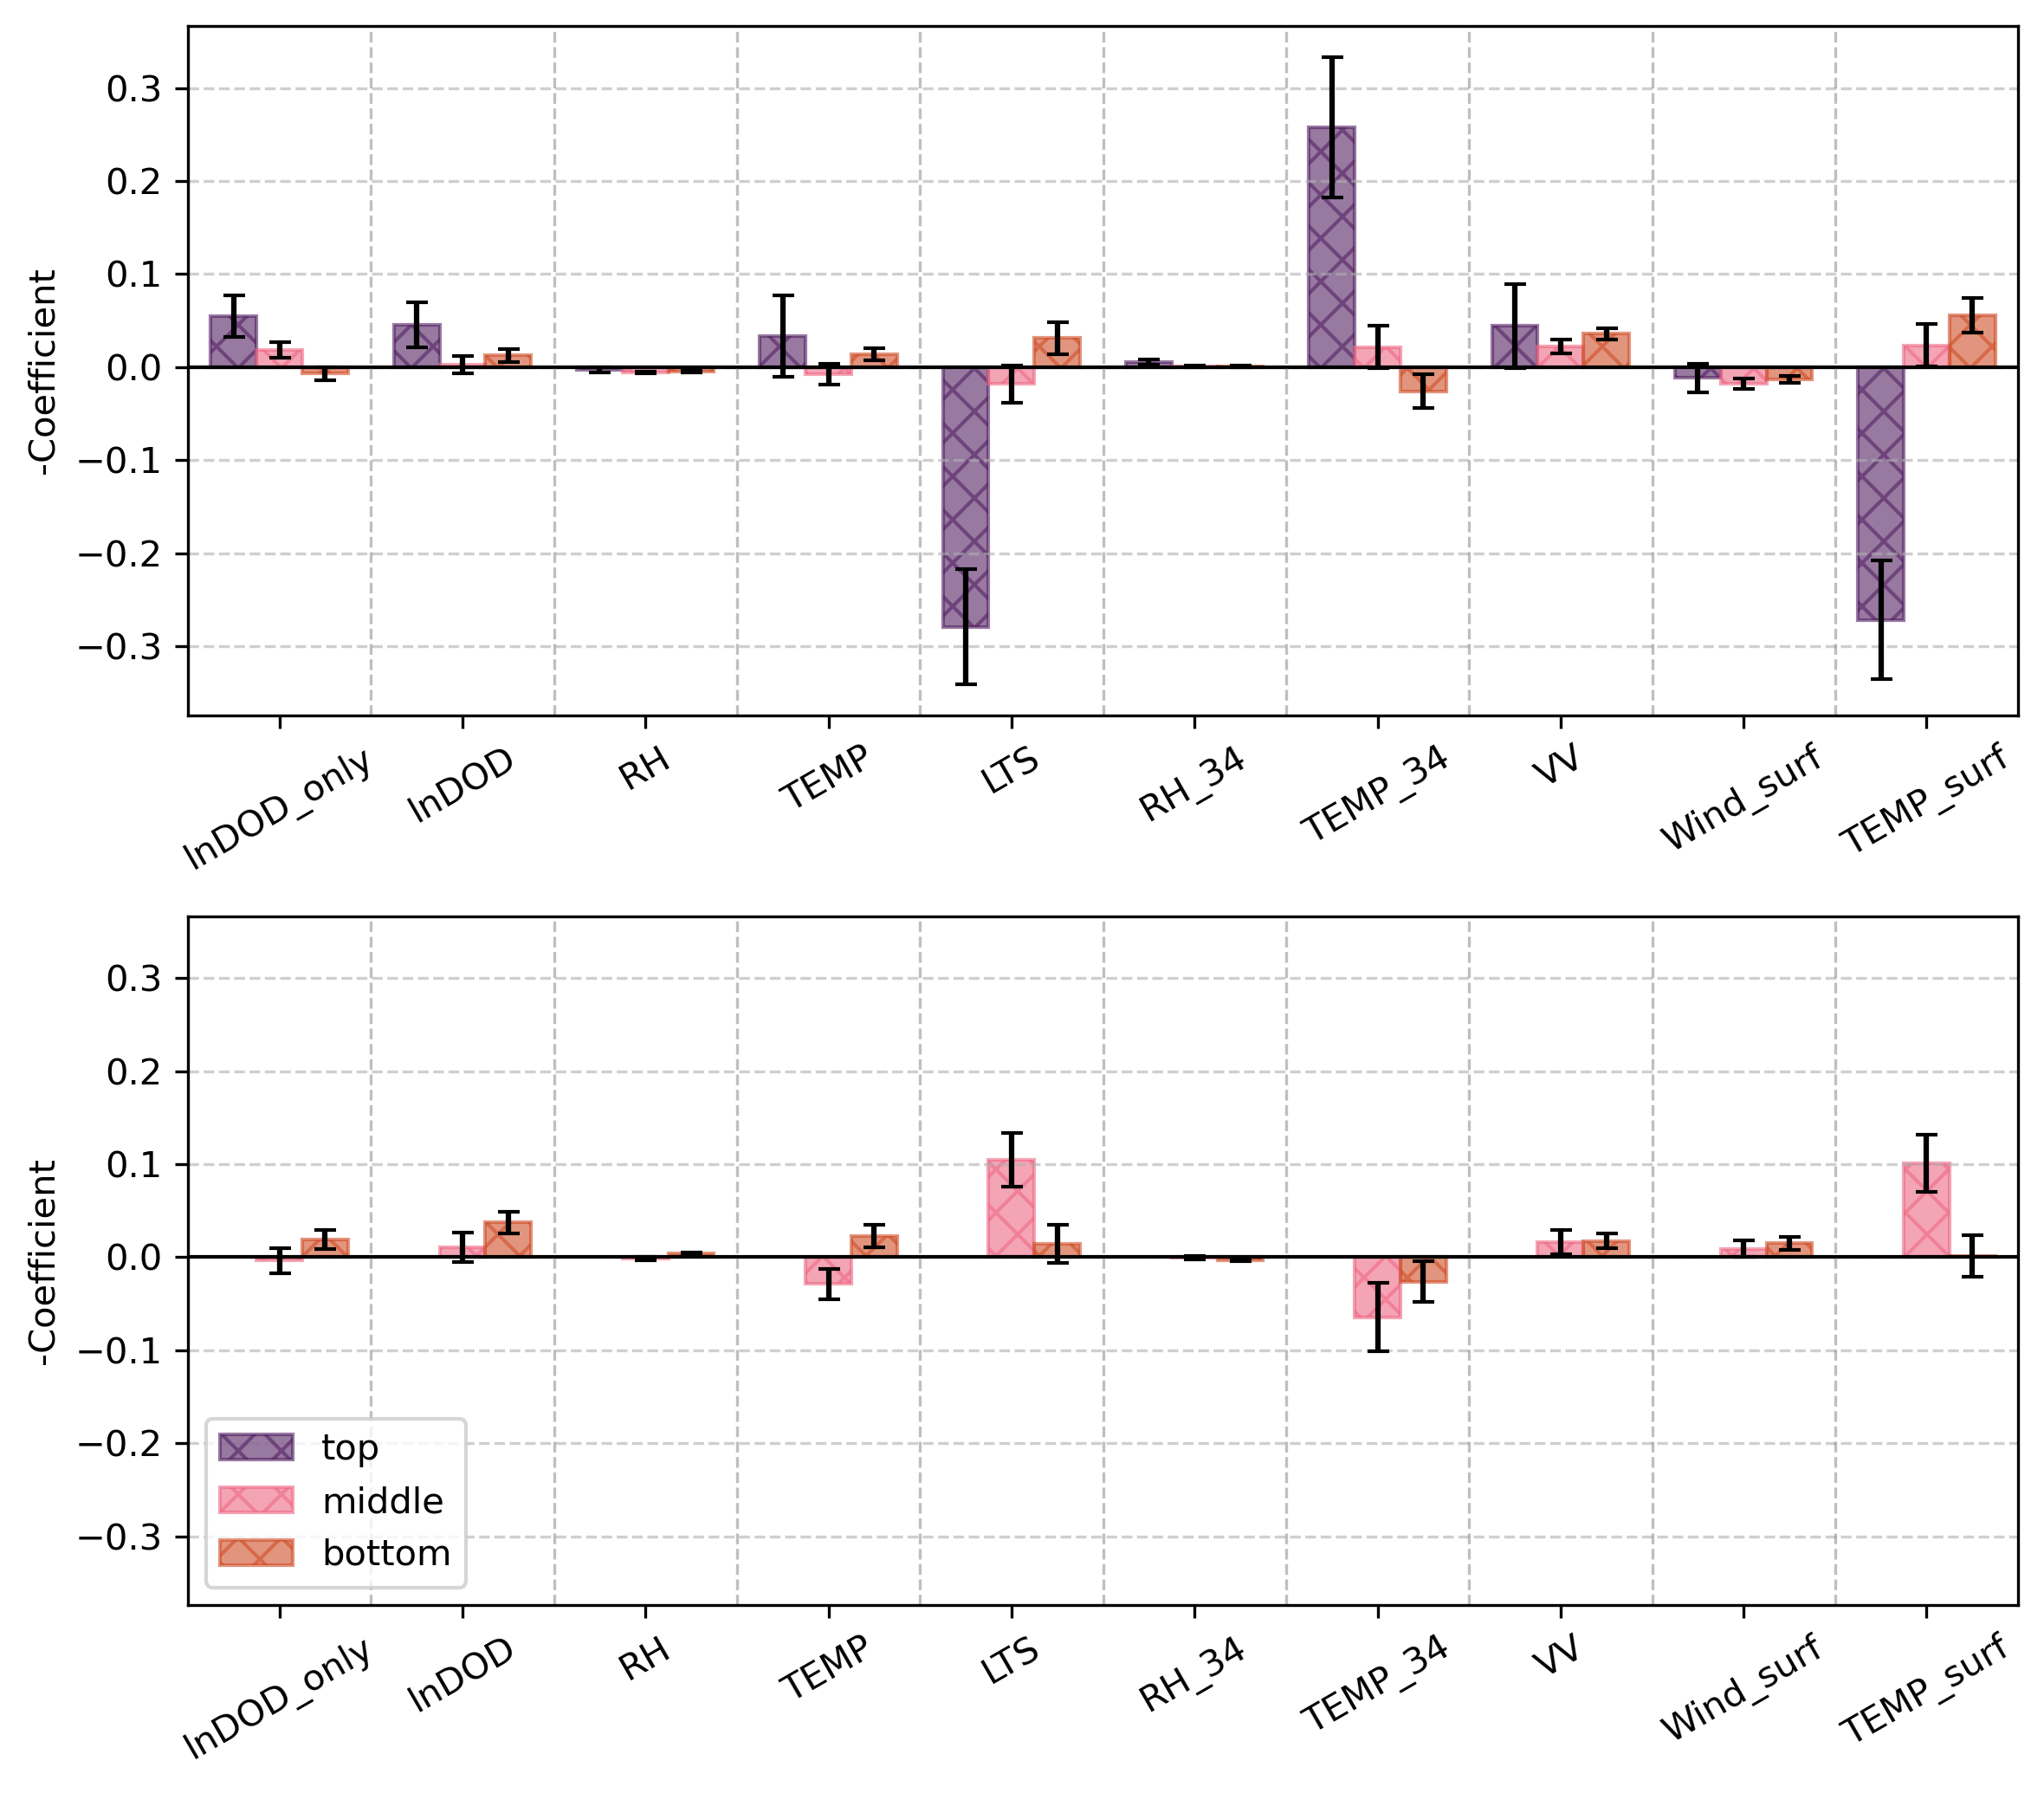

In [6]:
met_vars = ['RH','TEMP','LTS','RH_34','TEMP_34','VV','Wind_surf','TEMP_surf']
cats = ['top','middle','bottom']
cat_colors = {"top":"#532162","middle":"#ee6a85","bottom":"#cf4e28"}

def safe_log(x):
    x = x.astype(float)
    x[x <= 0] = np.nan
    return np.log(x)

def get_results(df, min_n=15):
    r = {}
    for c in cats:
        d = df[df['label'] == c][['Re','main_dod'] + met_vars].copy()
        d['lnRe'] = safe_log(d['Re'])
        d['lnDOD'] = safe_log(d['main_dod'])
        d = d.dropna()
        r[c] = None if len(d) < min_n else sm.OLS(d['lnRe'], sm.add_constant(d[['lnDOD'] + met_vars])).fit()
    return r

res_ena = get_results(df_ena_abs, min_n=15)
res_sgp = get_results(df_sgp_abs, min_n=15)

simple = [
    {'top':0.0550, 'middle':0.0185, 'bottom':-0.0069},
    {'top':np.nan, 'middle':-0.0036, 'bottom':0.0192}
]
se = [
    {'top':0.0226, 'middle':0.0081, 'bottom':0.0069},
    {'top':np.nan, 'middle':0.0133, 'bottom':0.0101}
]

vars_all = ['lnDOD'] + met_vars
vars_new = ['lnDOD_only'] + vars_all
x = np.arange(len(vars_new))
w = 0.25

fig, axes = plt.subplots(2, 1, figsize=(8,7), dpi=300, sharey=True)

for ax, res, s, e in zip(axes, [res_ena, res_sgp], simple, se):
    for i, c in enumerate(cats):
        if res[c] is None:
            vals = np.full(len(vars_new), np.nan)
            errs = np.full(len(vars_new), np.nan)
        else:
            p = res[c].params.reindex(['const'] + vars_all).drop('const')
            b = res[c].bse.reindex(['const'] + vars_all).drop('const')
            vals = np.concatenate(([s[c]], -p.values))
            errs = np.concatenate(([e[c]], b.values))

        ax.bar(x + (i-1)*w, vals, w, yerr=errs, capsize=3,
               color=cat_colors[c], edgecolor=cat_colors[c],
               alpha=0.6, hatch='xx', label=c)

    ax.axhline(0, lw=1, color='k')
    for xi in x[:-1]:
        ax.axvline(xi+0.5, ls='--', lw=0.8, color='gray', alpha=0.5)
    ax.grid(axis='y', ls='--', alpha=0.6)
    ax.set_xlim(-0.5, len(vars_new)-0.5)
    ax.margins(x=0)
    ax.set_xticks(x)
    ax.set_xticklabels(vars_new, rotation=30)
    ax.set_ylabel('-Coefficient')
axes[1].legend()

plt.tight_layout()
plt.show()

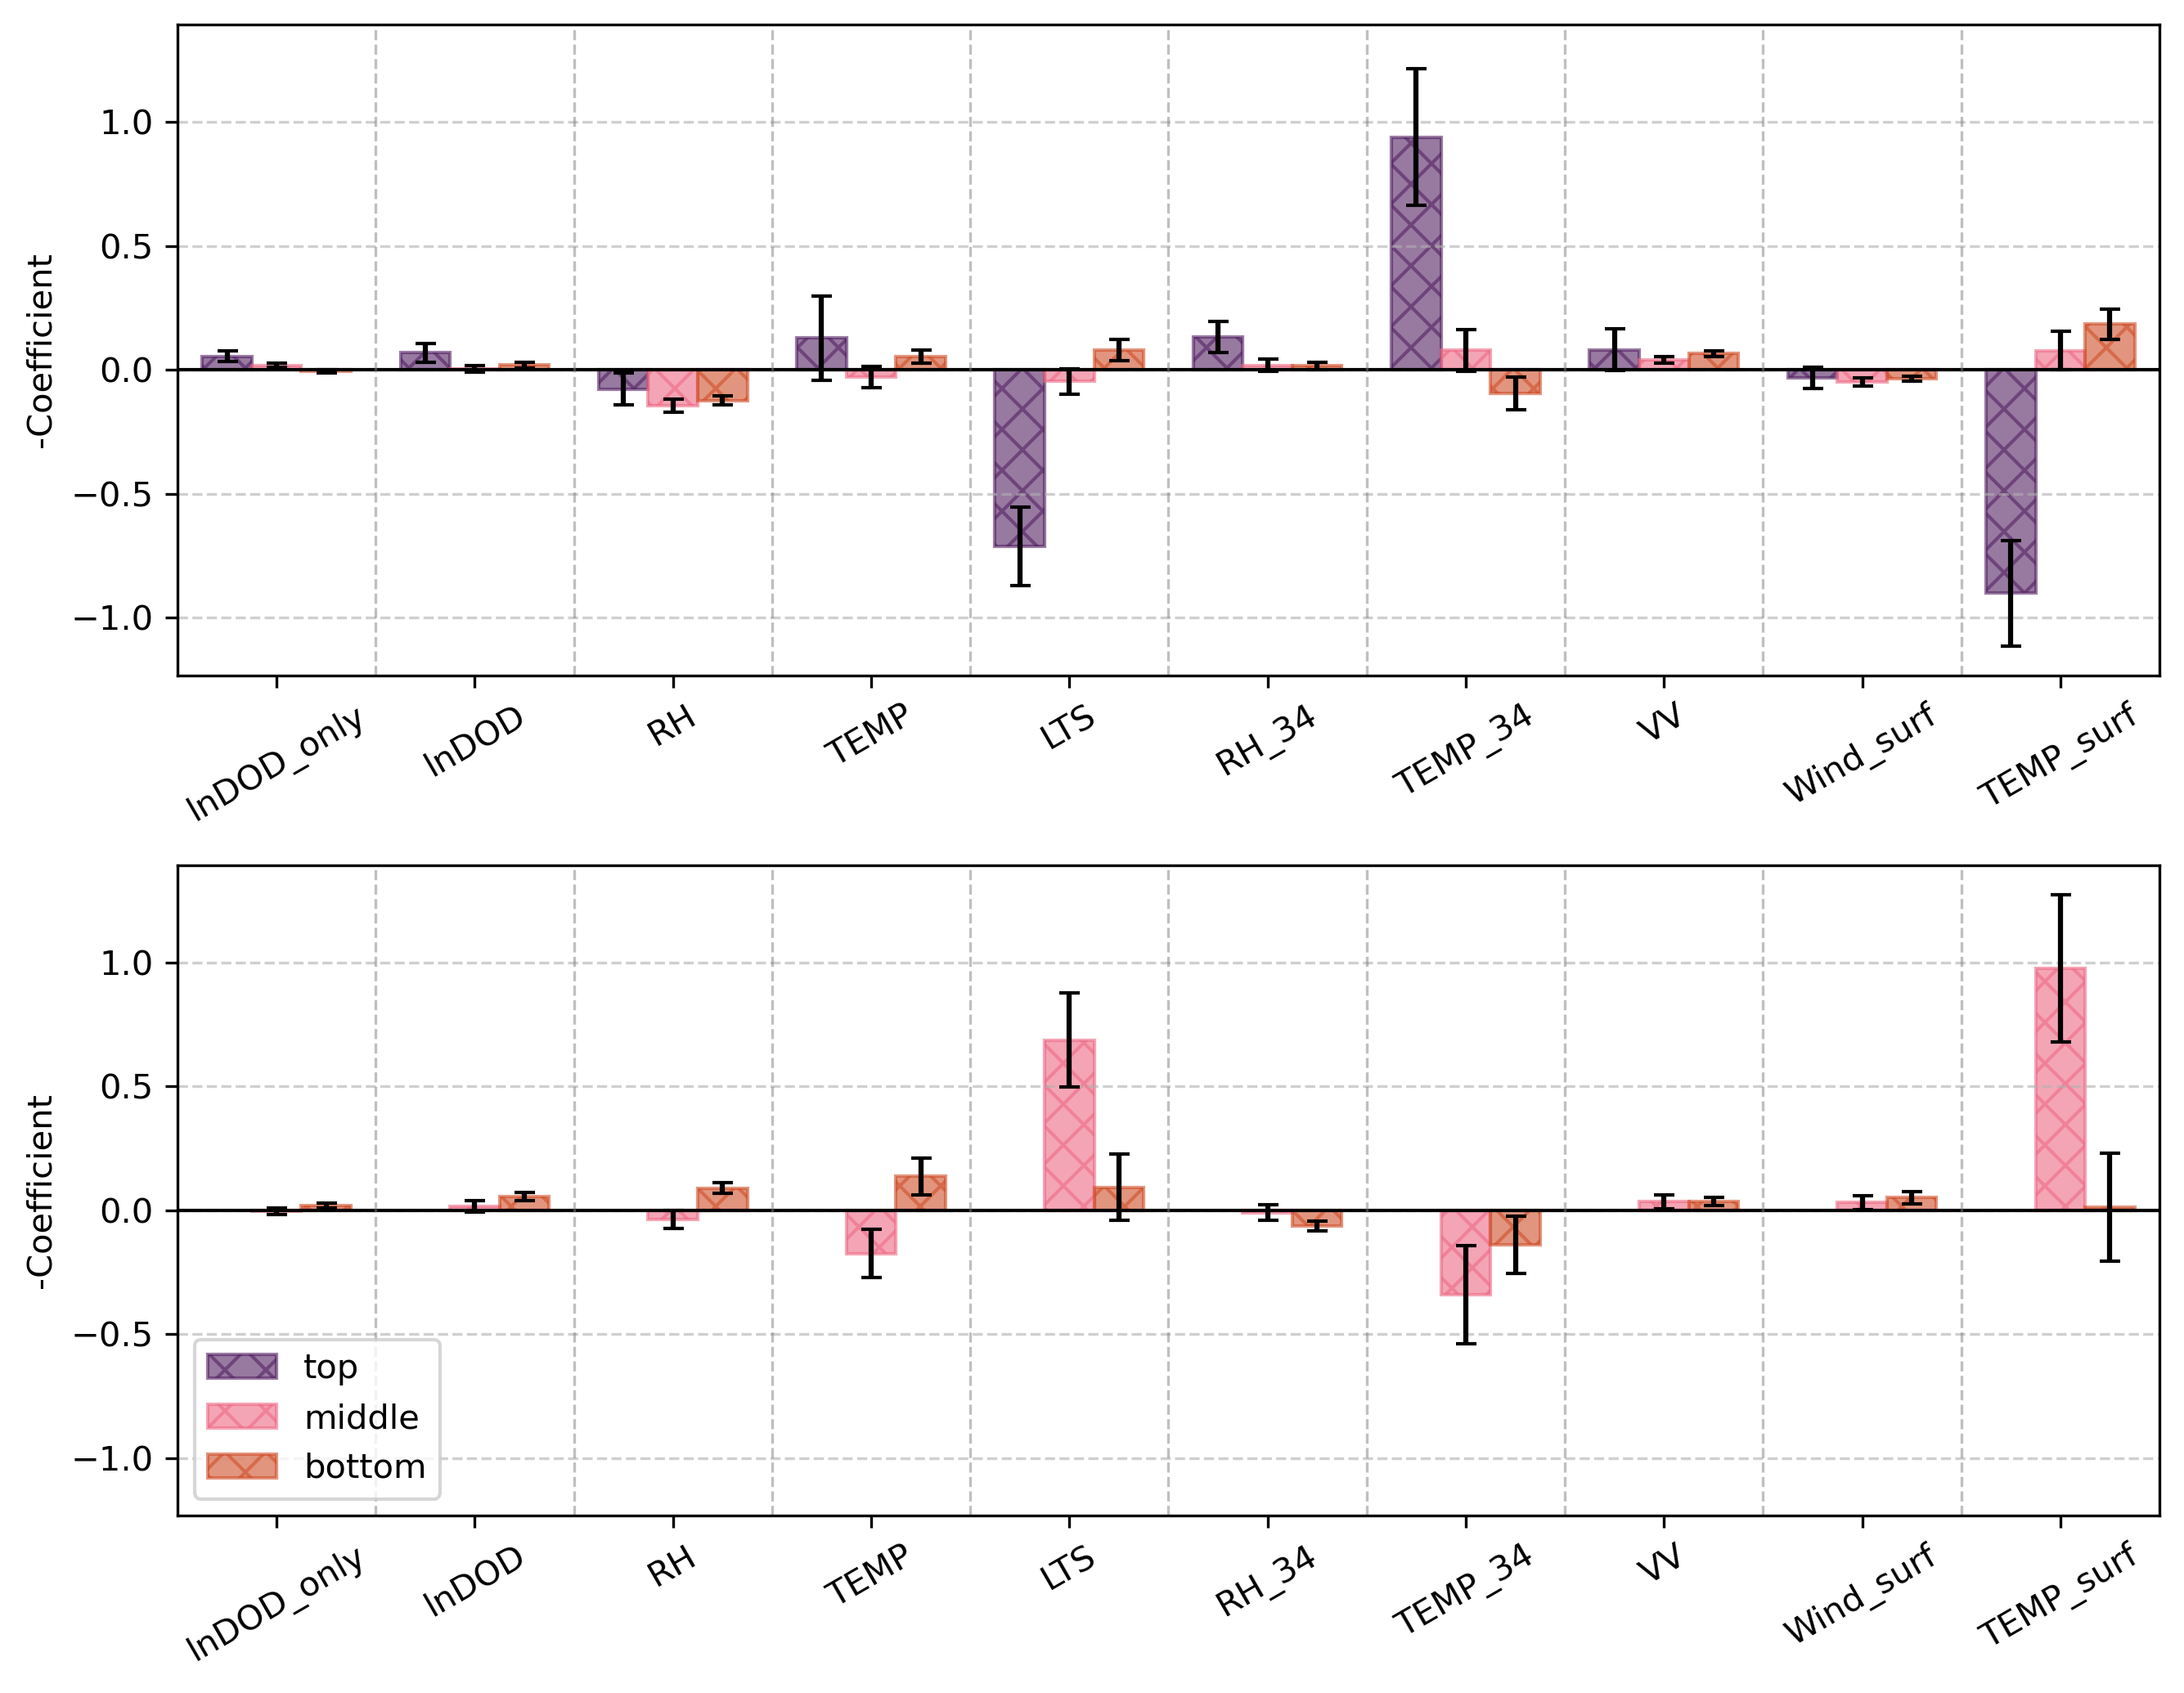

In [7]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

met_vars = ['RH','TEMP','LTS','RH_34','TEMP_34','VV','Wind_surf','TEMP_surf']
cats = ['top','middle','bottom']
cat_colors = {"top":"#532162","middle":"#ee6a85","bottom":"#cf4e28"}

def safe_log(x):
    x = x.astype(float)
    x[x <= 0] = np.nan
    return np.log(x)

def zscore(s):
    s = s.astype(float)
    sd = s.std()
    return (s - s.mean()) / sd if sd > 0 else np.nan

def prep_std_df(df):
    cols = ['label','Re','main_dod'] + met_vars
    d = df[cols].copy()
    d['lnRe'] = safe_log(d['Re'])
    d['lnDOD'] = safe_log(d['main_dod'])
    d = d.drop(columns=['Re','main_dod'])
    for v in ['lnDOD'] + met_vars:
        d[v] = zscore(d[v])
    return d

def get_results_std(df, min_n=15):
    d = prep_std_df(df)
    res = {}
    for c in cats:
        dc = d[d['label'] == c][['lnRe','lnDOD'] + met_vars].dropna().copy()
        res[c] = None if len(dc) < min_n else sm.OLS(dc['lnRe'], sm.add_constant(dc[['lnDOD'] + met_vars])).fit()
    return res

res_ena = get_results_std(df_ena_abs, min_n=15)
res_sgp = get_results_std(df_sgp_abs, min_n=15)

simple = [
    {'top':0.0550, 'middle':0.0185, 'bottom':-0.0069},
    {'top':np.nan, 'middle':-0.0036, 'bottom':0.0192}
]
se = [
    {'top':0.0226, 'middle':0.0081, 'bottom':0.0069},
    {'top':np.nan, 'middle':0.0133, 'bottom':0.0101}
]

vars_all = ['lnDOD'] + met_vars
vars_new = ['lnDOD_only'] + vars_all
x = np.arange(len(vars_new))
w = 0.25

fig, axes = plt.subplots(2, 1, figsize=(9, 7), dpi=300, sharey=True)

for ax, res, s, e,in zip(
    axes,
    [res_ena, res_sgp],
    simple,
    se,
):
    for i, c in enumerate(cats):
        if res[c] is None:
            vals = np.full(len(vars_new), np.nan)
            errs = np.full(len(vars_new), np.nan)
        else:
            p = res[c].params.reindex(['const'] + vars_all).drop('const')
            b = res[c].bse.reindex(['const'] + vars_all).drop('const')
            vals = np.concatenate(([s[c]], -p.values))
            errs = np.concatenate(([e[c]], b.values))

        ax.bar(
            x + (i-1)*w, vals, w, yerr=errs, capsize=3,
            color=cat_colors[c], edgecolor=cat_colors[c],
            alpha=0.6, hatch='xx', label=c
        )

    ax.axhline(0, lw=1, color='k')
    for xi in x[:-1]:
        ax.axvline(xi + 0.5, ls='--', lw=0.8, color='gray', alpha=0.5)
    ax.grid(axis='y', ls='--', alpha=0.6)
    ax.set_xlim(-0.5, len(vars_new)-0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(vars_new, rotation=30)
    ax.set_ylabel('-Coefficient')

axes[1].legend()
plt.tight_layout()
plt.show()

## XGBoost